In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import linopy as lp
import pypsa
print(pypsa.__version__)
import gurobipy as gp

print("Gurobi version:", gp.gurobi.version())

1.1.2
Gurobi version: (13, 0, 1)


In [84]:
%pip install linopy
%pip install gurobipy
%pip install pypsa matplotlib cartopy highspy
%pip install Gurobi
%pip install numpy
%pip install pandas


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement Gurobi (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for Gurobi
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart 

In [85]:
import xarray as xr
print(xr.__version__)

2026.2.0


In [86]:
# =====================
# LOAD DATA
# =====================

# load electricity demand data
df_elec = pd.read_csv('electricity_demand.csv', sep=';', index_col=0) # in MWh
df_elec.index = pd.to_datetime(df_elec.index) #change index to datatime
country='DEU'
print(df_elec[country].head())

# load onshore wind data
df_onshorewind = pd.read_csv('onshore_wind_1979-2017.csv', sep=';', index_col=0)
df_onshorewind.index = pd.to_datetime(df_onshorewind.index)

# load offshore wind data
df_offshorewind = pd.read_csv('offshore_wind_1979-2017.csv', sep=';', index_col=0)
df_offshorewind.index = pd.to_datetime(df_offshorewind.index)

# load large scale pv data
df_pv = pd.read_csv('pv_optimal.csv', sep=';', index_col=0)
df_pv.index = pd.to_datetime(df_pv.index)

# load rooftop pv data
df_rooftop = pd.read_csv('pv_rooftop.csv', sep=';', index_col=0)
df_rooftop.index = pd.to_datetime(df_rooftop.index)

utc_time
2015-01-01 00:00:00+00:00    44546.0
2015-01-01 01:00:00+00:00    42967.0
2015-01-01 02:00:00+00:00    41582.0
2015-01-01 03:00:00+00:00    40964.0
2015-01-01 04:00:00+00:00    40247.0
Name: DEU, dtype: float64


In [87]:
colors = {"onshore": "blue", "offshore": "darkblue", "pv": "orange", 
          "rooftop": "yellow", "coal": "brown", "OCGT": "grey"}

In [ ]:
# =====================
# MAKE NETWORK
# =====================
 
def annuity(n,r):
    """ Calculate the annuity factor for an asset with lifetime n years and
    discount rate  r """

    if r > 0:
        return r/(1. - 1./(1.+r)**n)
    else:
        return 1/n 

In [89]:
network = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

network.set_snapshots(hours_in_2015.values)

# add electricity bus
network.add("Bus",
            f"E_bus{country}")

# add load to the bus
network.add("Load",
            "load",
            bus=f"E_bus{country}",
            p_set=df_elec[country].values)

# add the different carriers, only gas emits CO2
network.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
network.add("Carrier", "coal", co2_emissions=0.9) # in t_CO2/MWh_th
network.add("Carrier", "onshorewind")
network.add("Carrier", "offshorewind")
network.add("Carrier", "solarPV")
network.add("Carrier", "rooftopPV")

''' Add renewable generators '''
# Add onshore wind
CF_wind_onshore = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
lifetime = 30 # years
discount_rate = 0.07 # 7%
capex = 910000 # in €/MW
fopex = 0.033 # 3.3% of capex
capital_cost_onshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
network.add("Generator",
            "onshorewind",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="onshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_onshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind_onshore.values)

# Add offshore wind
CF_wind_offshore = df_offshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 2506000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_offshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
network.add("Generator",
            "offshorewind",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="offshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_offshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind_offshore.values)

# Add large scale solar
CF_solar = df_pv[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 425000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_pv = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
network.add("Generator",
            "PV",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="solarPV",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_pv,
            marginal_cost = 0,
            p_max_pu = CF_solar.values)

# Add rooftop solar
CF_rooftop = df_rooftop[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 725000 # in €/MW
fopex = 0.02 # 2% of capex
capital_cost_rooftop = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
network.add("Generator",
            "rooftopPV",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="rooftopPV",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_rooftop,
            marginal_cost = 0,
            p_max_pu = CF_rooftop.values)

''' Add non-renewables generators '''
# add OCGT (Open Cycle Gas Turbine) generator
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 560000 # in €/MW
fopex = 0.033 # 3.3% of capex
capital_cost_OCGT = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
fuel_cost = 21.6 # in €/MWh_th
efficiency = 0.39 # MWh_elec/MWh_th
marginal_cost_OCGT = fuel_cost/efficiency # in €/MWh_el
network.add("Generator",
            "OCGT",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="gas",
            #p_nom_max=1000,
            capital_cost = capital_cost_OCGT,
            efficiency = efficiency,
            marginal_cost = marginal_cost_OCGT)

# add coal generator (without CCS) # https://atb-archive.nrel.gov/electricity/2018/index.html?t=cc
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 3294000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_coal = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
fuel_cost = 4 # in €/MWh_th 
efficiency = 0.36 # MWh_elec/MWh_th
marginal_cost_coal = fuel_cost/efficiency # in €/MWh_el
network.add("Generator",
            "coal",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="coal",
            #p_nom_max=1000,
            capital_cost = capital_cost_coal,
            efficiency = efficiency,
            marginal_cost = marginal_cost_coal)



In [90]:
network.optimize(solver_name='gurobi')

/var/folders/6w/b824ws7s0yvdbd5wwn1806680000gn/T/ipykernel_27477/3854944838.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi')
Index(['E_busDEU'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 128.78it/s]
INFO:linopy.io: Writing time: 0.12s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2788995


INFO:gurobipy:Set parameter LicenseID to value 2788995


...

Solved in 13312 iterations and 3.89 seconds (1.07 work units)


INFO:gurobipy:Solved in 13312 iterations and 3.89 seconds (1.07 work units)


Optimal objective  2.475321425e+10


INFO:gurobipy:Optimal objective  2.475321425e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 2.48e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [44]:
Print Out the Results

SyntaxError: invalid syntax (3330630411.py, line 1)

In [91]:
if network.objective is None:
    print("Optimization failed or was not run. Check solver logs.")
else:
    # Now it is safe to calculate your costs
    total_cost = network.objective / 1e6
    print(f"Total cost: {round(total_cost, 2)} mio€")
    
    # Calculate total load consumption
    total_load = network.loads_t.p.sum().sum() 
    if total_load > 0:
        cost_per_mwh = network.objective / total_load
        print(f"Cost per MWh: {round(cost_per_mwh, 2)} EUR/MWh")
    else:
        print("Total load is zero, cannot calculate cost per MWh.")

Total cost: 24753.21 mio€
Cost per MWh: 48.99 EUR/MWh


(np.float64(-1.0999999610572813),
 np.float64(1.0999999981455848),
 np.float64(-1.0999999845940491),
 np.float64(1.1000000044956866))

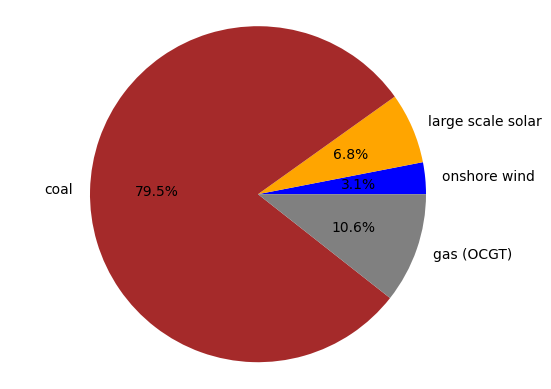

In [92]:
labels = ['onshore wind',
            #'offshore wind',
            'large scale solar',
            #'rooftop solar',
            'coal',
            'gas (OCGT)']
       
sizes = [network.generators_t.p['onshorewind'].sum(),
            #network.generators_t.p['offshorewind'].sum(),
         network.generators_t.p['PV'].sum(),
            #network.generators_t.p['rooftopPV'].sum(),
            network.generators_t.p['coal'].sum(),
         network.generators_t.p['OCGT'].sum()]

colors=['blue', 'orange', 'brown', 'grey']

plt.pie(sizes,
        colors=colors,
        labels=labels,
        wedgeprops={'linewidth':0},
        autopct='%1.1f%%')
plt.axis('equal')

In [93]:
network.generators.p_nom_opt.div(1e3) # in GW

name
onshorewind      8.350420
offshorewind     0.000000
PV              33.368777
rooftopPV        0.000000
OCGT            28.614407
coal            48.134363
Name: p_nom_opt, dtype: float64

In [94]:
print(f"Onshore max: {network.generators_t.p['onshorewind'].max()}")
print(f"Offshore max: {network.generators_t.p['offshorewind'].max()}")

Onshore max: 6504.977209085271
Offshore max: 0.0


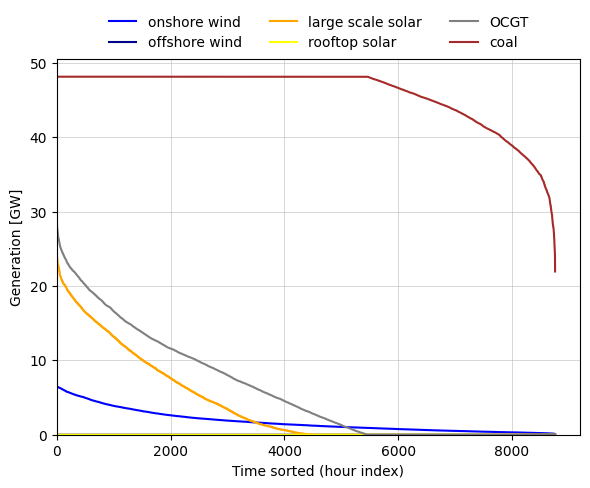

In [95]:
colors = ['blue', 'darkblue', 'orange', 'yellow', 'brown', 'grey']

# Duration Curves (in GW)
cf_onshore = network.generators_t.p['onshorewind'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_offshore = network.generators_t.p['offshorewind'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_PV = network.generators_t.p['PV'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_rooftopPV = network.generators_t.p['rooftopPV'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_OCGT = network.generators_t.p['OCGT'].sort_values(ascending=False, ignore_index=True) / 1e3
cf_coal = network.generators_t.p['coal'].sort_values(ascending=False, ignore_index=True) / 1e3

x_axis = range(8760)

plt.figure(figsize=(6, 5))

plt.plot(x_axis, cf_onshore, color='blue')
plt.plot(x_axis, cf_offshore, color='darkblue')
plt.plot(x_axis, cf_PV, color='orange')
plt.plot(x_axis, cf_rooftopPV, color='yellow')
plt.plot(x_axis, cf_OCGT, color='grey')
plt.plot(x_axis, cf_coal, color='brown')

plt.grid(True, which='both', linewidth=0.5, alpha=0.7)
plt.ylabel('Generation [GW]')
plt.xlabel('Time sorted (hour index)')

# Force axes to start at 0
plt.ylim(bottom=0)
plt.xlim(left=0)

# Legend on top center
plt.legend(['onshore wind', 'offshore wind', 'large scale solar', 'rooftop solar', 'OCGT', 'coal'],
           loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)

plt.tight_layout()
plt.show()


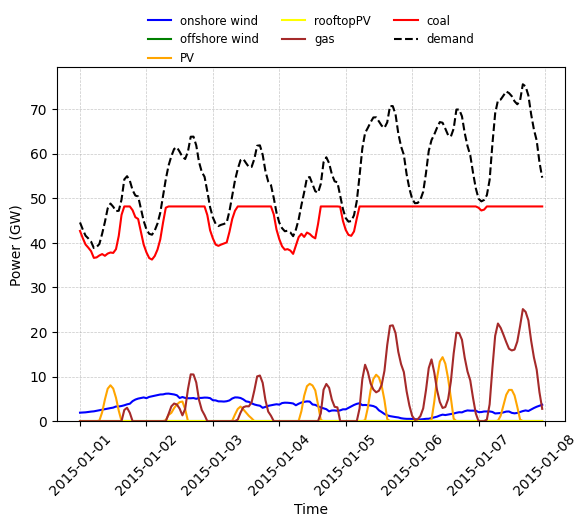

In [96]:
start_date_1 = '2015-01-01'
end_date_1 = '2015-01-07'
week_1 = network.generators_t.p.loc[start_date_1:end_date_1] / 1e3  # Convert to GW
demand = network.loads_t.p['load'].loc[start_date_1:end_date_1] / 1e3  # Convert to GW

plt.figure(figsize=(6, 5.5))

plt.plot(week_1['onshorewind'], color='blue', label='onshore wind')
plt.plot(week_1['offshorewind'], color='green', label='offshore wind')
plt.plot(week_1['PV'], color='orange', label='PV')
plt.plot(week_1['rooftopPV'], color='yellow', label='rooftopPV')
plt.plot(week_1['OCGT'], color='brown', label='gas')
plt.plot(week_1['coal'], color='red', label='coal')
plt.plot(demand, color='black', label='demand', linestyle='--')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.ylim(bottom=0)
plt.xlabel('Time')
plt.ylabel('Power (GW)')  # Updated unit
plt.xticks(rotation=45)

plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.18),
           ncol=3,
           fontsize='small',
           frameon=False)

plt.tight_layout()
plt.show()

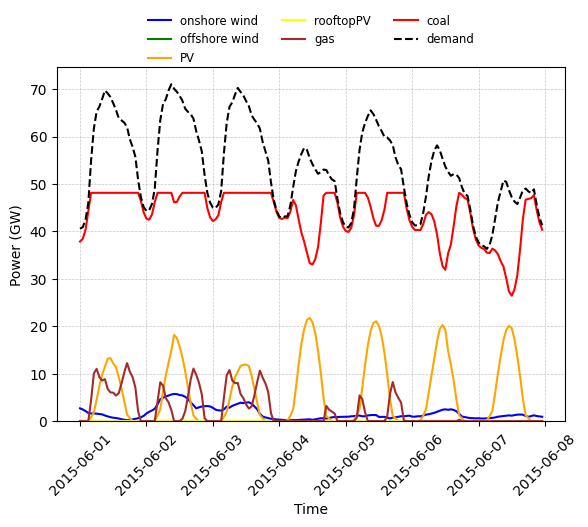

In [97]:
# Summer week time slice
start_date_2 = '2015-06-01'
end_date_2 = '2015-06-07'
week_2 = network.generators_t.p.loc[start_date_2:end_date_2] / 1e3  # Convert to GW
demand_2 = network.loads_t.p['load'].loc[start_date_2:end_date_2] / 1e3  # Convert to GW

plt.figure(figsize=(6, 5.5))

plt.plot(week_2['onshorewind'], color='blue', label='onshore wind')
plt.plot(week_2['offshorewind'], color='green', label='offshore wind')
plt.plot(week_2['PV'], color='orange', label='PV')
plt.plot(week_2['rooftopPV'], color='yellow', label='rooftopPV')
plt.plot(week_2['OCGT'], color='brown', label='gas')
plt.plot(week_2['coal'], color='red', label='coal')
plt.plot(demand_2, color='black', label='demand', linestyle='--')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.ylim(bottom=0)
plt.xlabel('Time')
plt.ylabel('Power (GW)')
plt.xticks(rotation=45)

plt.legend(loc='upper center',
           bbox_to_anchor=(0.5, 1.18),
           ncol=3,
           fontsize='small',
           frameon=False)

plt.tight_layout()
plt.show()


In [98]:
(network.statistics.capex() + network.statistics.opex()).div(1e6)

component  carrier    
Generator  coal           18478.567500
           gas             4388.622204
           onshorewind             NaN
           solarPV                 NaN
dtype: float64

In [ ]:
Task B

In [99]:
print(network.generators_t.p_max_pu.shape)
print(type(network.generators_t.p_max_pu["onshorewind"].iloc[0]))

(8760, 4)
<class 'numpy.float64'>


Index(['E_busDEU'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')


Optimizing for year: 2001


INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 82.26it/s]
INFO:linopy.io: Writing time: 0.19s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:


Solved in 0 iterations and 0.13 seconds (0.06 work units)


INFO:gurobipy:Solved in 0 iterations and 0.13 seconds (0.06 work units)


Optimal objective  0.000000000e+00


INFO:gurobipy:Optimal objective  0.000000000e+00
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 0.00e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


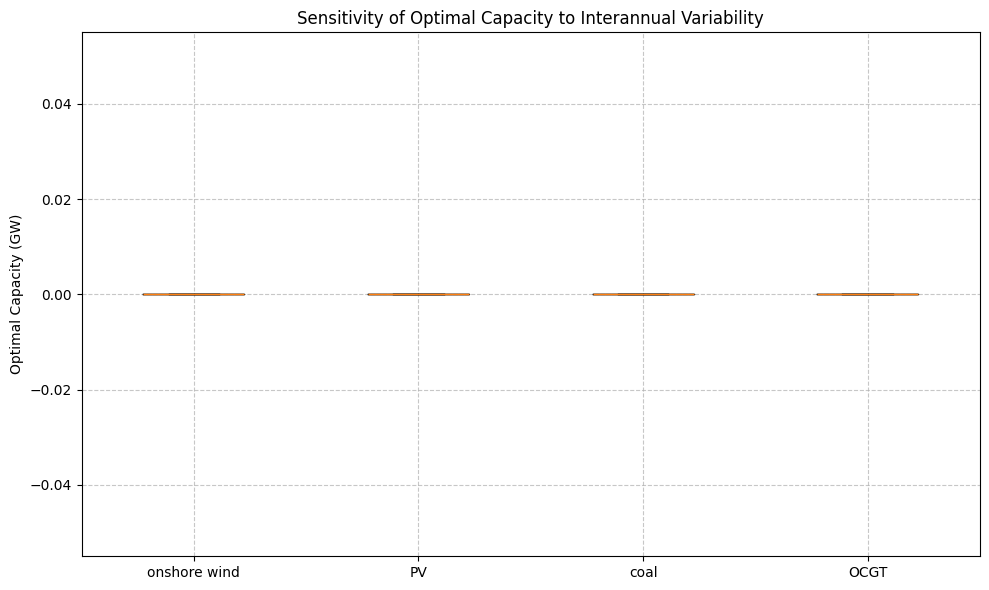

Capacity Statistics (GW):
       onshorewind    PV  coal  OCGT
count         13.0  13.0  13.0  13.0
mean           0.0   0.0   0.0   0.0
std            0.0   0.0   0.0   0.0
min            0.0   0.0   0.0   0.0
25%            0.0   0.0   0.0   0.0
50%            0.0   0.0   0.0   0.0
75%            0.0   0.0   0.0   0.0
max            0.0   0.0   0.0   0.0


In [ ]:

# 1. Define the years to analyze (excluding those you might want to skip)
years = df_offshorewind.index.year.unique()
years = years[(years >= 2001) & (years != 2016) & (years != 2012) & (years != 2008) & (years != 2004)]

# Lists to store results
systemcost = []
onwind_cap = []
pv_cap = []
coal_cap = []
ocgt_cap = []

for year in years:
    print(f"Optimizing for year: {year}")
    
    # Reset network results/state
    network.results = None
    network.lopf = None
    
    # All lines below must be indented by exactly 4 spaces:
    network.generators_t.p_max_pu["onshorewind"] = df_onshorewind[country][df_onshorewind.index.year == year].values.flatten()
    network.generators_t.p_max_pu["offshorewind"] = df_offshorewind[country][df_offshorewind.index.year == year].values.flatten()
    network.generators_t.p_max_pu["PV"] = df_pv[country][df_pv.index.year == year].values.flatten()
    network.generators_t.p_max_pu["rooftopPV"] = df_rooftop[country][df_rooftop.index.year == year].values.flatten()
    
    # Ensure this line is also indented 4 spaces
    network.optimize(solver_name="gurobi", include_objective_constant=False)
    
    # Store results (also indented 4 spaces)
    systemcost.append(network.objective / 1e6)
    onwind_cap.append(network.generators.p_nom_opt.loc["onshorewind"])
    pv_cap.append(network.generators.p_nom_opt.loc["PV"])
    coal_cap.append(network.generators.p_nom_opt.loc["coal"])
    ocgt_cap.append(network.generators.p_nom_opt.loc["OCGT"])

# 3. Compile results into a DataFrame
results = pd.DataFrame(
    np.array([onwind_cap, pv_cap, coal_cap, ocgt_cap]).T / 1e3, # Convert to GW
    columns=["onshorewind", "PV", "coal", "OCGT"],
    index=years
)

# 4. Create Boxplot for Variability Analysis
plt.figure(figsize=(10, 6))
plt.boxplot(
    [results["onshorewind"], results["PV"], results["coal"], results["OCGT"]],
    tick_labels=["onshore wind", "PV", "coal", "OCGT"]
)
plt.ylabel("Optimal Capacity (GW)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Sensitivity of Optimal Capacity to Interannual Variability")
plt.tight_layout()
plt.show()

# 5. Print Summary Statistics for your report
print("Capacity Statistics (GW):")
print(results.describe())

In [128]:
years = df_offshorewind.index.year.unique()
years = years[(years >= 2001) & (years != 2016) & (years != 2012) & (years != 2008) & (years != 2004)]


systemcost = []
onwind = []
#offwind = []
pv = []
#rooftop = []
coal = []
ocgt = []

onwind_cap = []
#offwind_cap = []
pv_cap = []
#rooftop_cap = []
coal_cap = []
ocgt_cap = []


for year in years:
    network.generators_t.p_max_pu["onshorewind"] = df_onshorewind[country][df_onshorewind.index.year == year].values
    network.generators_t.p_max_pu["offshorewind"] = df_offshorewind[country][df_offshorewind.index.year == year].values
    network.generators_t.p_max_pu["PV"] = df_pv[country][df_pv.index.year == year].values
    network.generators_t.p_max_pu["rooftopPV"] = df_rooftop[country][df_rooftop.index.year == year].values
    
    network.optimize(solver_name="gurobi")
    systemcost.append(network.objective / 1e6)  # in million euros
    onwind.append(network.generators_t.p["onshorewind"].sum())
    #offwind.append(network.generators_t.p["offshorewind"].sum())
    pv.append(network.generators_t.p["PV"].sum())
    #rooftop.append(network.generators_t.p["rooftopPV"].sum())
    coal.append(network.generators_t.p["coal"].sum())
    ocgt.append(network.generators_t.p["OCGT"].sum())

    onwind_cap.append(network.generators.p_nom_opt.loc["onshorewind"])
    #offwind_cap.append(network.generators.p_nom_opt.loc["offshorewind"])
    pv_cap.append(network.generators.p_nom_opt.loc["PV"])
    #rooftop_cap.append(network.generators.p_nom_opt.loc["rooftopPV"])
    coal_cap.append(network.generators.p_nom_opt.loc["coal"])
    ocgt_cap.append(network.generators.p_nom_opt.loc["OCGT"])

/var/folders/6w/b824ws7s0yvdbd5wwn1806680000gn/T/ipykernel_27477/3577266733.py:27: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name="gurobi")
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 127.79it/s]
INFO:linopy.io: Writing time: 0.11s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2788995


INFO:gurobipy:Set parameter LicenseID to value 2788995


...

INFO:gurobipy:


Solved in 0 iterations and 0.13 seconds (0.06 work units)


INFO:gurobipy:Solved in 0 iterations and 0.13 seconds (0.06 work units)


Optimal objective  0.000000000e+00


INFO:gurobipy:Optimal objective  0.000000000e+00
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 0.00e+00
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


In [ ]:
Section C

In [137]:
n = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

n.set_snapshots(hours_in_2015.values)

# add electricity bus
n.add("Bus",
            f"E_bus{country}")

# add load to the bus
n.add("Load",
            "load",
            bus=f"E_bus{country}",
            p_set=df_elec[country].values)

# add the different carriers, only gas emits CO2
n.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
n.add("Carrier", "coal", co2_emissions=0.9) # in t_CO2/MWh_th
n.add("Carrier", "onshorewind")
n.add("Carrier", "offshorewind")
n.add("Carrier", "solarPV")
n.add("Carrier", "rooftopPV")

''' Add renewable generators '''
# Add onshore wind
CF_wind_onshore = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
lifetime = 30 # years
discount_rate = 0.07 # 7%
capex = 910000 # in €/MW
fopex = 0.033 # 3.3% of capex
capital_cost_onshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
n.add("Generator",
            "onshorewind",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="onshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_onshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind_onshore.values)
'''
# Add offshore wind
CF_wind_offshore = df_offshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 2506000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_offshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
n.add("Generator",
            "offshorewind",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="offshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_offshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind_offshore.values)
'''
# Add large scale solar
CF_solar = df_pv[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 425000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_pv = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
n.add("Generator",
            "PV",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="solarPV",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_pv,
            marginal_cost = 0,
            p_max_pu = CF_solar.values)
'''
# Add rooftop solar
CF_rooftop = df_rooftop[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 725000 # in €/MW
fopex = 0.02 # 2% of capex
capital_cost_rooftop = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
n.add("Generator",
            "rooftopPV",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="rooftopPV",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_rooftop,
            marginal_cost = 0,
            p_max_pu = CF_rooftop.values)
'''

''' Add non-renewables generators '''
# add OCGT (Open Cycle Gas Turbine) generator
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 560000 # in €/MW
fopex = 0.033 # 3.3% of capex
capital_cost_OCGT = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
fuel_cost = 21.6 # in €/MWh_th
efficiency = 0.39 # MWh_elec/MWh_th
marginal_cost_OCGT = fuel_cost/efficiency # in €/MWh_el
n.add("Generator",
            "OCGT",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="gas",
            #p_nom_max=1000,
            capital_cost = capital_cost_OCGT,
            efficiency = efficiency,
            marginal_cost = marginal_cost_OCGT)

# add coal generator (without CCS) # https://atb-archive.nrel.gov/electricity/2018/index.html?t=cc
lifetime = 25 # years
discount_rate = 0.07 # 7%
capex = 3294000 # in €/MW
fopex = 0.03 # 3% of capex
capital_cost_coal = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
fuel_cost = 4 # in €/MWh_th 
efficiency = 0.36 # MWh_elec/MWh_th
marginal_cost_coal = fuel_cost/efficiency # in €/MWh_el
n.add("Generator",
            "coal",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            carrier="coal",
            #p_nom_max=1000,
            capital_cost = capital_cost_coal,
            efficiency = efficiency,
            marginal_cost = marginal_cost_coal)


# Add storage unit
n.add("StorageUnit",
            "battery",
            bus=f"E_bus{country}",
            p_nom_extendable=True,
            capital_cost=12894+24678,
            efficiency_dispatch=0.96,
            efficiency_store=0.96,
            max_hours=2,
            cyclic_state_of_charge=True,)

# Co2 Cap
n.add(
    "GlobalConstraint",
    "CO2Limit",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant=152000000, #152MtCO2
)

KeyError: "None of [Index(['2015-01-01T00:00:00Z', '2015-01-01T01:00:00Z', '2015-01-01T02:00:00Z',\n       '2015-01-01T03:00:00Z', '2015-01-01T04:00:00Z', '2015-01-01T05:00:00Z',\n       '2015-01-01T06:00:00Z', '2015-01-01T07:00:00Z', '2015-01-01T08:00:00Z',\n       '2015-01-01T09:00:00Z',\n       ...\n       '2015-12-31T14:00:00Z', '2015-12-31T15:00:00Z', '2015-12-31T16:00:00Z',\n       '2015-12-31T17:00:00Z', '2015-12-31T18:00:00Z', '2015-12-31T19:00:00Z',\n       '2015-12-31T20:00:00Z', '2015-12-31T21:00:00Z', '2015-12-31T22:00:00Z',\n       '2015-12-31T23:00:00Z'],\n      dtype='str', name='utc_time', length=8760)] are in the [index]"

In [138]:
n.optimize(solver_name='gurobi')

/var/folders/6w/b824ws7s0yvdbd5wwn1806680000gn/T/ipykernel_27477/2340880384.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name='gurobi')
Index(['E_busDEU'], dtype='str', name='name')


IndexError: list index out of range

In [ ]:
n.generators_t.p.loc["2015-01"].plot.area(figsize=(12, 4), ylabel="dispatch", color=['blue', 'orange', 'brown', 'grey'])


In [ ]:
labels = ['onshore wind',
            #'offshore wind',
            'large scale solar',
            'coal',
            'gas (OCGT)']
      
sizes = [n.generators_t.p['onshorewind'].sum(),
         #n.generators_t.p['offshorewind'].sum(),
         n.generators_t.p['PV'].sum(),
         n.generators_t.p['coal'].sum(),
         n.generators_t.p['OCGT'].sum()]
 
colors=['blue', 'orange', 'brown', 'grey']
 
plt.figure(figsize=(6, 4))
plt.pie(
    sizes,
    colors=colors,
    labels=labels,
    autopct='%1.1f%%',  # Show percentages with 1 decimal place
    pctdistance=0.8,
    textprops={'fontsize': 12},
    startangle=0,      # Optional: rotate start for aesthetic
    wedgeprops={'linewidth': 0}
)
plt.axis('equal')  # Keeps pie chart circular
plt.legend(fancybox=True, shadow=True, loc='right')
#plt.title('Generation Mix', y=1.07, fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
# Storage installed capacity
print(f"Installed capacity of storage: {n.storage_units.p_nom_opt.loc['battery'] / 1e3} GW")

In [ ]:
n.storage_units_t.p.loc["2015-01"].plot(figsize=(6, 2), ylabel="battery")

In [ ]:
battery_power = n.storage_units_t.p.loc["2015"]

# Charging (negative) and Discharging (positive)
charging_power = battery_power.where(battery_power < 0, 0)
discharging_power = battery_power.where(battery_power > 0, 0)

# Monthly sums in GWh
monthly_charging = charging_power.resample("ME").sum() / 1e3
monthly_discharging = discharging_power.resample("ME").sum() / 1e3
demand = n.loads_t.p.loc["2015", "load"].resample("ME").sum() / 1e3

# Plot
fig, ax1 = plt.subplots(figsize=(10, 4))

# Primary axis: charging/discharging
line1, = ax1.plot(monthly_charging.index, monthly_charging, label="Charging", color="blue", marker='o')
line2, = ax1.plot(monthly_discharging.index, monthly_discharging, label="Discharging", color="orange", marker='o')
ax1.set_ylabel("Charged (-) and Discharged (+) Energy (GWh)")
ax1.set_xlabel("Month")
ax1.grid(True, alpha=0.3)

# Secondary axis: demand
ax2 = ax1.twinx()
line3, = ax2.plot(demand.index, demand, label="Demand", color="green", marker='o')
ax2.set_ylabel("Demand (GWh)")

# Combine legends from both axes and place them on top
lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
day = "2015-09-05"

# Get all generator names
generators = n.generators.index

# Filter out rooftopPV and offshorewind
filtered_generators = generators[~generators.str.contains("rooftopPV|offshorewind")]

# Convert generator dispatch to GW
gen_dispatch_gw = n.generators_t.p.loc[day, filtered_generators] / 1e3

# Plot filtered generators
ax = gen_dispatch_gw.plot.area(
    figsize=(6, 4),
    ylabel="Dispatch [GW]",
    legend=False,  # We'll use a custom combined legend
    color=['blue', 'orange', 'brown', 'grey']
)

# Overlay demand and storage (in GW)
line_demand = (n.loads_t.p['load'].loc[day] / 1e3).plot(
    ax=ax, linewidth=2, linestyle="--", color="yellow", label="Demand"
)
line_battery = (n.storage_units_t.p.loc[day] / 1e3).plot(
    ax=ax, drawstyle="steps-post", linewidth=2.5, linestyle="--", color="black", label="Battery"
)

# Combine and move legend to top center
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)

plt.ylim(-20, 80)
plt.tight_layout()
plt.show()

In [ ]:
# Duration Curves
cf_onshore = n.generators_t.p['onshorewind'].sort_values(ascending=False,ignore_index=True)/1e3
#cf_offshore = n.generators_t.p['offshorewind'].sort_values(ascending=False,ignore_index=True)/1e3
cf_PV = n.generators_t.p['PV'].sort_values(ascending=False,ignore_index=True)/1e3
#cf_rooftopPV = n.generators_t.p['rooftopPV'].sort_values(ascending=False,ignore_index=True)/1e3
cf_OCGT = n.generators_t.p['OCGT'].sort_values(ascending=False,ignore_index=True)/1e3
cf_coal = n.generators_t.p['coal'].sort_values(ascending=False,ignore_index=True)/1e3


cf_onshore.plot(kind='line', ylabel='CF onshore', color='blue')
#cf_offshore.plot(kind='line', ylabel='CF offshore', color='darkblue')
cf_PV.plot(kind='line', ylabel='CF PV', color='orange')
#cf_rooftopPV.plot(kind='line', ylabel='CF rooftopPV', color='yellow')
cf_OCGT.plot(kind='line', ylabel='CF OCGT', color='grey')
cf_coal.plot(kind='line', ylabel='CF coal', color='brown')
plt.title('Duration Curves of the different generators')
plt.legend(['onshore wind', 'large scale solar', 'OCGT', 'coal'])
plt.ylabel('Generation [GW]')
plt.show()

In [ ]:
n.generators.p_nom_opt.div(1e3) # in GW

In [ ]:
print(f"Total cost: {round(n.objective/1000000,2)} mio€")
print(f"Cost per MWh of electricity produced {round(float(n.objective/n.loads_t.p.sum().iloc[0]))} EUR/MWh")


In [ ]:
day = "2015-01-05"
ax = n.generators_t.p.loc[day].plot.area(figsize=(12, 4), ylabel="Dispatch [MW]", legend=True)

# 2. Overlay storage unit dispatch as step lines
n.storage_units_t.p.loc[day].plot(ax=ax, drawstyle="steps-post", linewidth=2, linestyle="--", legend=True)

# 3. Customize
plt.title(f"Dispatch on {day}")
plt.tight_layout()
plt.ylim(-10000, 80000)
plt.show()

Task D


In [139]:
import os
print(os.getcwd())

/Users/alexandrasonidou/Documents/University Courses/Semester 3/Integrated Grid Analysis/Assignment


In [141]:
# load electricity demand data
df_elec = pd.read_csv('electricity_demand.csv', sep=';', index_col=0) # in MWh
df_elec.index = pd.to_datetime(df_elec.index) #change index to datatime

# load onshore wind data
df_onshorewind = pd.read_csv('onshore_wind_1979-2017.csv', sep=';', index_col=0)
df_onshorewind.index = pd.to_datetime(df_onshorewind.index)

# load offshore wind data
df_offshorewind = pd.read_csv('offshore_wind_1979-2017.csv', sep=';', index_col=0)
df_offshorewind.index = pd.to_datetime(df_offshorewind.index)

# load large scale pv data
df_pv = pd.read_csv('pv_optimal.csv', sep=';', index_col=0)
df_pv.index = pd.to_datetime(df_pv.index)

# load rooftop pv data
df_rooftop = pd.read_csv('pv_rooftop.csv', sep=';', index_col=0)
df_rooftop.index = pd.to_datetime(df_rooftop.index)

# load hydro inflow in Austria
df_hydro = pd.read_csv('Hydro_Inflow_AT.csv')  # assumes columns: Year, Month, Day, Inflow [GWh]
df_hydro['date'] = pd.to_datetime(df_hydro[['Year', 'Month', 'Day']])
df_hydro.set_index('date', inplace=True)

# Convert from GWh/day → MW (spread evenly across 24 hours)
df_hydro['inflow_MW'] = df_hydro['Inflow [GWh]'] * 1000 / 24
## Align to model snapshots
df_hydro_hourly = df_hydro['inflow_MW'].resample('h').ffill()


hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

df_hydro_inflow = pd.DataFrame(index=hours_in_2015)
df_hydro_inflow['inflow_MW'] = df_hydro_hourly.loc[df_hydro_hourly.index.year==2011].values

In [142]:
colors = {"onshore": "blue", "offshore": "darkblue", "pv": "orange", 
          "rooftop": "yellow", "coal": "brown", "OCGT": "grey"}

In [143]:
def annuity(n,r):
    """ Calculate the annuity factor for an asset with lifetime n years and
    discount rate  r """

    if r > 0:
        return r/(1. - 1./(1.+r)**n)
    else:
        return 1/n

In [144]:
n = pypsa.Network()
n.set_snapshots(hours_in_2015.values)

# add the different carriers, only gas emits CO2
n.add("Carrier", "gas", co2_emissions=0.19)   # in t_CO2/MWh_th
n.add("Carrier", "coal", co2_emissions=0.9)   # in t_CO2/MWh_th
n.add("Carrier", "onshorewind")
n.add("Carrier", "offshorewind")
n.add("Carrier", "solarPV")
n.add("Carrier", "rooftopPV")
n.add("Carrier", "hydro")

# countries in the model
countries = ['DEU', 'DNK', 'AUT', 'NLD']

# coordinates (latitude, longitude)
coordinates = {
    'DNK': (55.67, 12.57),   # Copenhagen
    'DEU': (52.37, 9.73),    # Hannover
    'AUT': (47.57, 14.23),   # Liezen
    'NLD': (52.37, 4.90)     # Amsterdam
}

# add electricity buses
for country in countries:
    n.add("Bus",
          country,
          y=coordinates[country][0],
          x=coordinates[country][1],
          carrier="AC")
    
# add load to the bus
    n.add("Load",
                f"load{country}",
                bus=country,
                p_set=df_elec[country].values)


    ''' Add renewable generators '''
    if country != 'AUT':
        # Add onshore wind
        CF_wind_onshore = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
        lifetime = 30 # years
        discount_rate = 0.07 # 7%
        capex = 910000 # in €/MW
        fopex = 0.033 # 3.3% of capex
        capital_cost_onshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
        n.add("Generator",
              f"onshorewind{country}",
                    bus=country,
                    p_nom_extendable=True,
                    carrier="onshorewind",
                    #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
                    capital_cost = capital_cost_onshorewind,
                    marginal_cost = 0,
                    p_max_pu = CF_wind_onshore.values)
        
        # Add offshore wind
        CF_wind_offshore = df_offshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
        lifetime = 25 # years
        discount_rate = 0.07 # 7%
        capex = 2506000 # in €/MW
        fopex = 0.03 # 3% of capex
        capital_cost_offshorewind = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
        n.add("Generator",
                    f"offshorewind{country}",
                    bus=country,
                    p_nom_extendable=True,
                    carrier="offshorewind",
                    #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
                    capital_cost = capital_cost_offshorewind,
                    marginal_cost = 0,
                    p_max_pu = CF_wind_offshore.values)
        # Add large scale solar
    CF_solar = df_pv[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
    lifetime = 25 # years
    discount_rate = 0.07 # 7%
    capex = 425000 # in €/MW
    fopex = 0.03 # 3% of capex
    capital_cost_pv = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
    n.add("Generator",
                f"PV{country}",
                bus=country,
                p_nom_extendable=True,
                carrier="solarPV",
                #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
                capital_cost = capital_cost_pv,
                marginal_cost = 0,
                p_max_pu = CF_solar.values)
    ''' Add non-renewables generators '''
    # add OCGT (Open Cycle Gas Turbine) generator
    lifetime = 25 # years
    discount_rate = 0.07 # 7%
    capex = 560000 # in €/MW
    fopex = 0.033 # 3.3% of capex
    capital_cost_OCGT = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
    fuel_cost = 21.6 # in €/MWh_th
    efficiency = 0.39 # MWh_elec/MWh_th
    marginal_cost_OCGT = fuel_cost/efficiency # in €/MWh_el
    n.add("Generator",
                f"OCGT{country}",
                bus=country,
                p_nom_extendable=True,
                carrier="gas",
                #p_nom_max=1000,
                capital_cost = capital_cost_OCGT,
                efficiency = efficiency,
                marginal_cost = marginal_cost_OCGT)
    if country == 'DEU':
        # add coal generator (without CCS) # https://atb-archive.nrel.gov/electricity/2018/index.html?t=cc
        lifetime = 25 # years
        discount_rate = 0.07 # 7%
        capex = 3294000 # in €/MW
        fopex = 0.03 # 3% of capex
        capital_cost_coal = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
        fuel_cost = 4 # in €/MWh_th 
        efficiency = 0.36 # MWh_elec/MWh_th
        marginal_cost_coal = fuel_cost/efficiency # in €/MWh_el
        n.add("Generator",
                    f"coal{country}",
                    bus=country,
                    p_nom_extendable=True,
                    carrier="coal",
                    #p_nom_max=1000,
                    capital_cost = capital_cost_coal,
                    efficiency = efficiency,
                    marginal_cost = marginal_cost_coal)
        
    if country == 'AUT':
        lifetime = 80 # years
        discount_rate = 0.07 # 7%
        capex = 300000 # in €/MW
        fopex = 0.02 # 2% of capex
        capital_cost_hydro = annuity(lifetime,discount_rate)*capex*(1+fopex) # in €/MW
        marginal_cost_hydro = 0

        n.add("StorageUnit",
            name=f"hydro{country}",
            bus=country,
            p_nom_extendable=True,
            capital_cost=capital_cost_hydro,
            marginal_cost=0,
            efficiency_store=1.0,       # inflow enters fully
            efficiency_dispatch=0.9,    # turbine efficiency
            max_hours=500,             # max energy storage in MWh per MW of power capacity
            inflow=df_hydro_inflow.values.flatten(),  # energy inflow time series in MW
            carrier="hydro")
        
         # Add storage unit
    n.add("StorageUnit",
                f"battery{country}",
                bus=country,
                p_nom_extendable=True,
                capital_cost=12894+24678,
                efficiency_dispatch=0.96,
                efficiency_store=0.96,
                max_hours=12,
                cyclic_state_of_charge=True)

In [145]:
# Add AC lines between the countries
distances = {
    ("DEU", "DNK"): 406,  # km
    ("DEU", "AUT"): 622,  # km
    ("DNK", "AUT"): 909,  # km
    ("DEU", "NLD"): 240,  # km
    ("DNK", "NLD"): 620   # km
}

capital_cost_lines = 400  # in €/MW/km

# DEU-DNK
n.add(
    "Line",
    "DEU-DNK",
    bus0="DEU",
    bus1="DNK",
    s_nom=3650,
    x=1,
    r=1,
    # capital_cost=capital_cost_lines * distances[("DEU", "DNK")],
    # s_nom_extendable=True
)

# DEU-AUT
n.add(
    "Line",
    "DEU-AUT",
    bus0="DEU",
    bus1="AUT",
    s_nom=4700,
    x=1,
    r=1,
    # capital_cost=capital_cost_lines * distances[("DEU", "AUT")],
    # s_nom_extendable=True
)
# DNK-AUT
n.add(
    "Line",
    "DNK-AUT",
    bus0="DNK",
    bus1="AUT",
    s_nom=1500,
    x=1,
    r=1,
    # capital_cost=capital_cost_lines * distances[("DNK", "AUT")],
    # s_nom_extendable=True
)

# DEU-NLD
n.add(
    "Line",
    "DEU-NLD",
    bus0="DEU",
    bus1="NLD",
    s_nom=3650,
    x=1,
    r=1,
    # capital_cost=capital_cost_lines * distances[("DEU", "NLD")],
    # s_nom_extendable=True
)

# DNK-NLD
n.add(
    "Line",
    "DNK-NLD",
    bus0="DNK",
    bus1="NLD",
    s_nom=2000,
    x=1,
    r=1,
    # capital_cost=capital_cost_lines * distances[("DNK", "NLD")],
    # s_nom_extendable=True
)

In [146]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
DEU-DNK,DEU,DNK,,1.0,1.0,0.0,0.0,3650.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DEU-AUT,DEU,AUT,,1.0,1.0,0.0,0.0,4700.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DNK-AUT,DNK,AUT,,1.0,1.0,0.0,0.0,1500.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DEU-NLD,DEU,NLD,,1.0,1.0,0.0,0.0,3650.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DNK-NLD,DNK,NLD,,1.0,1.0,0.0,0.0,2000.0,0.0,False,...,-inf,inf,,0.0,0.0,0.0,0.0,0.0,0.0,0.0


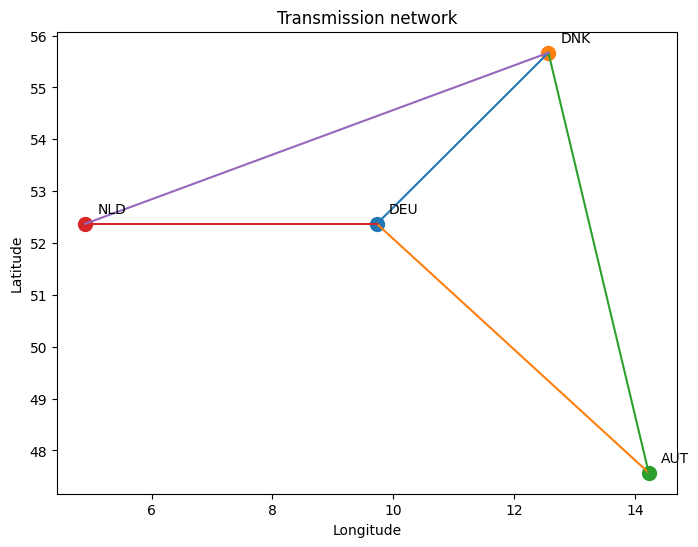

In [147]:
fig, ax = plt.subplots(figsize=(8,6))

# plot buses
for bus_name, bus in n.buses.iterrows():
    ax.scatter(bus["x"], bus["y"], s=100)
    ax.text(bus["x"]+0.2, bus["y"]+0.2, bus_name, fontsize=10)

# plot lines
for line_name, line in n.lines.iterrows():
    x0 = n.buses.loc[line["bus0"], "x"]
    y0 = n.buses.loc[line["bus0"], "y"]
    x1 = n.buses.loc[line["bus1"], "x"]
    y1 = n.buses.loc[line["bus1"], "y"]
    ax.plot([x0, x1], [y0, y1])

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Transmission network")
plt.show()

In [148]:
# Co2 Cap
CO2_limit = (152 + 4.9 + 6.0) #MtCO2 just electricity

n.add(
    "GlobalConstraint",
    "CO2Limit",
    carrier_attribute="co2_emissions",
    sense="<=",
    constant= CO2_limit * 1000000, #152MtCO2 for GE + 6.0 for DK (https://www.nowtricity.com/country/denmark/) + 4.9 for AT (https://www.nowtricity.com/country/austria)
)

In [149]:
n.optimize(solver_name='gurobi')

/var/folders/6w/b824ws7s0yvdbd5wwn1806680000gn/T/ipykernel_27477/2340880384.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name='gurobi')
Index(['DEU', 'DNK', 'AUT', 'NLD'], dtype='str', name='name')
Index(['DEU-DNK', 'DEU-AUT', 'DNK-AUT', 'DEU-NLD', 'DNK-NLD'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 74.61it/s]
INFO:linopy.io: Writing time: 0.65s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2788995


INFO:gurobipy:Set parameter LicenseID to value 2788995


...

Solved in 154896 iterations and 263.62 seconds (198.86 work units)


INFO:gurobipy:Solved in 154896 iterations and 263.62 seconds (198.86 work units)


Optimal objective  3.460875937e+10


INFO:gurobipy:Optimal objective  3.460875937e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 315380 primals, 709581 duals
Objective: 3.46e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [150]:
colors

{'onshore': 'blue',
 'offshore': 'darkblue',
 'pv': 'orange',
 'rooftop': 'yellow',
 'coal': 'brown',
 'OCGT': 'grey'}

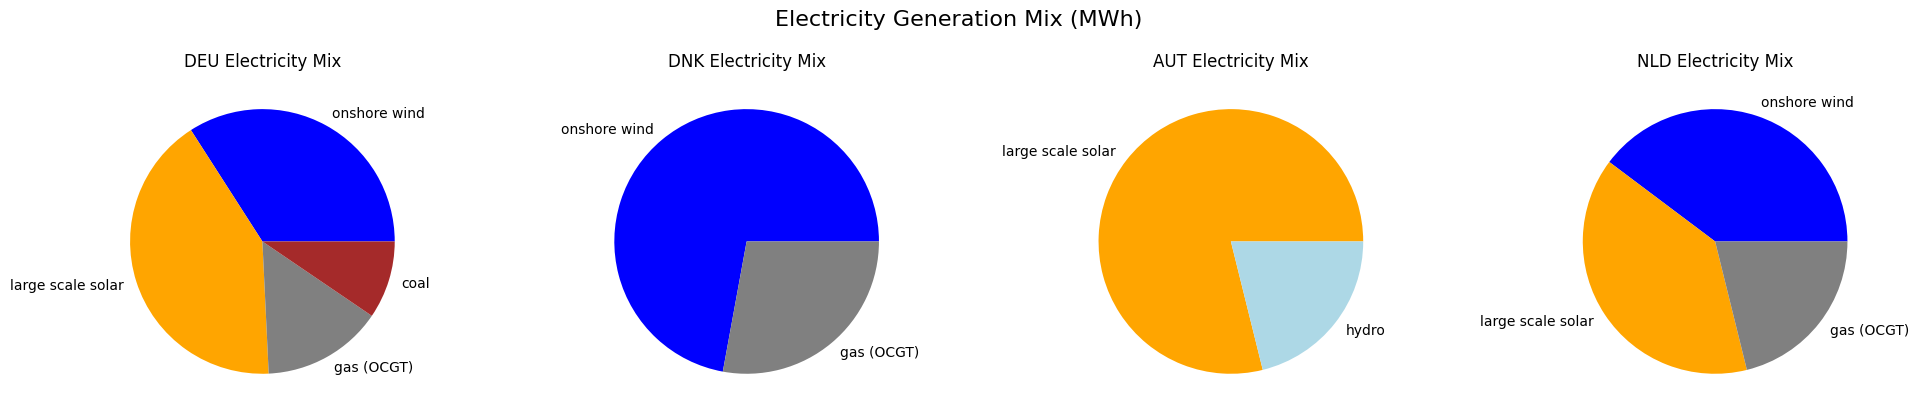

In [155]:
colors_gen = {
    'onshore wind': 'blue',
    'offshore wind': 'darkblue',
    'large scale solar': 'orange',
    'gas (OCGT)': 'grey',
    'coal': 'brown',
    'hydro': 'lightblue'
}

plt.figure(figsize=(20, 4))

for i, country in enumerate(countries):
    labels = []
    sizes = []

    # Onshore wind
    if f'onshorewind{country}' in n.generators.index:
        value = n.generators_t.p[f'onshorewind{country}'].sum()
        if value > 0.1:
            labels.append('onshore wind')
            sizes.append(value)

    # Offshore wind
    if f'offshorewind{country}' in n.generators.index:
        value = n.generators_t.p[f'offshorewind{country}'].sum()
        if value > 0.1:
            labels.append('offshore wind')
            sizes.append(value)

    # PV
    if f'PV{country}' in n.generators.index:
        value = n.generators_t.p[f'PV{country}'].sum()
        if value > 0.1:
            labels.append('large scale solar')
            sizes.append(value)

    # OCGT
    if f'OCGT{country}' in n.generators.index:
        value = n.generators_t.p[f'OCGT{country}'].sum()
        if value > 0.1:
            labels.append('gas (OCGT)')
            sizes.append(value)

    # Coal
    if f'coal{country}' in n.generators.index:
        value = n.generators_t.p[f'coal{country}'].sum()
        if value > 0.1:
            labels.append('coal')
            sizes.append(value)

    # Hydro (storage unit dispatch)
    if f"hydro{country}" in n.storage_units.index:
        value = n.storage_units_t.p[f"hydro{country}"].sum()
        if value > 0.1:
            labels.append('hydro')
            sizes.append(value)

    if sizes:
        colors = [colors_gen[label] for label in labels]
        plt.subplot(1, len (countries), i + 1)
        plt.pie(sizes, labels=labels, colors=colors, wedgeprops={'linewidth': 0})
        plt.axis('equal')
        plt.title(f"{country} Electricity Mix", y=1.07)
    else:
        plt.subplot(1, len (countries), i + 1)
        plt.text(0.5, 0.5, 'No generation', ha='center', va='center')
        plt.axis('off')

plt.suptitle("Electricity Generation Mix (MWh)", fontsize=16)
plt.tight_layout()
plt.show()


<Axes: xlabel='snapshot'>

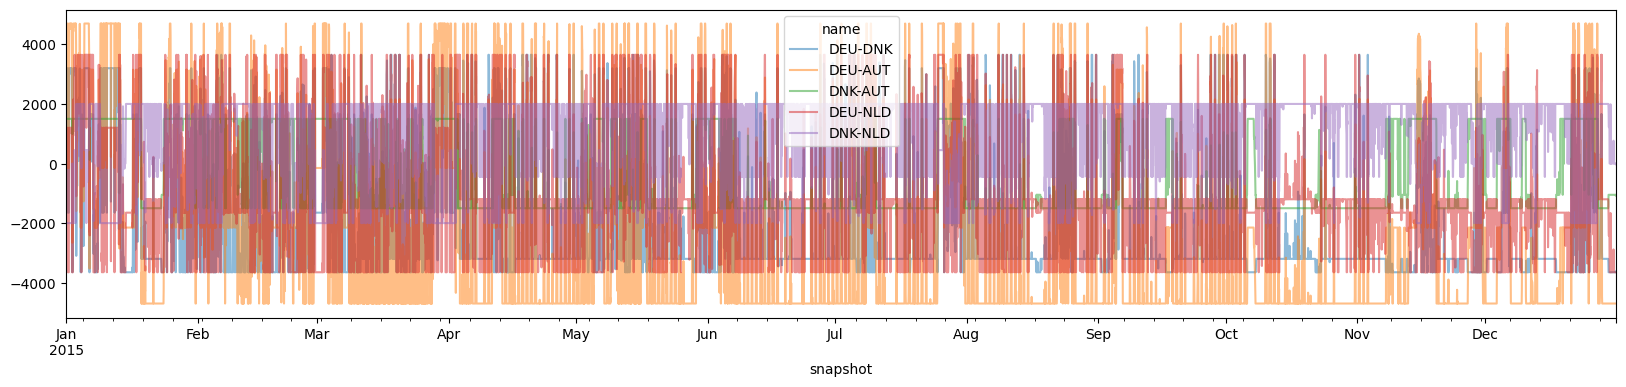

In [156]:
n.lines_t.p0.plot(figsize=(20, 4), alpha=0.5)